# Experiment 3: human data

Raw data comes from `npm run getdata` (saved in the repo's `data/` folder).

In [1]:
import json
from datetime import date
from pathlib import Path
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── settings: edit these ─────────────────────────────────────────────
DATA_FILE = Path('../../data/real-all-main-data.json')  # from `npm run getdata`
START_DATE = '2026-10-06'  # first day to include (published on Prolific 2026-10-06)
END_DATE = None            # last day to include, e.g. '2026-10-10'; None = up to today
TIMEZONE = 'America/New_York'  # dates are read in this time zone

In [2]:
# load every participant record, keep those who started within the date range, then those who finished
raw = json.loads(DATA_FILE.read_text())

def start_date(rec):
    ts = rec['data']['starttime']['_seconds']
    return pd.Timestamp(ts, unit='s', tz='UTC').tz_convert(TIMEZONE).date()

start = date.fromisoformat(START_DATE)
end = date.fromisoformat(END_DATE) if END_DATE else date.max
started = [r for r in raw if start <= start_date(r) <= end]
records = [r for r in started if r['data']['done'] and not r['data']['withdrawn']]
withdrew = [r for r in started if r['data']['withdrawn']]
left = [r for r in started if not r['data']['done'] and not r['data']['withdrawn']]

print(f'{len(started)} participants started between {START_DATE} and {END_DATE or "today"}')
print(f'  {len(records)} finished  <- analysed below')
print(f'  {len(withdrew)} withdrew' + (f" ({', '.join(r['id'][:8] for r in withdrew)})" if withdrew else ''))
print(f'  {len(left)} started but did not finish' + (f" ({', '.join(r['id'][:8] for r in left)})" if left else ''))

18 participants started between 2026-10-06 and today
  16 finished  <- analysed below
  1 withdrew (MBHKBOZY)
  1 started but did not finish (hV13o7q1)


## Trials table

One row per trial (12 per participant), from `pageData_exp`.

In [3]:
rows = []
for r in records:
    for visit in r['data']['pageData_exp'].values():
        for t in visit['data']:
            if 'choice' not in t:   # the end-of-task screen, not a trial
                continue
            rows.append({'participant': r['id'], **t})
trials = pd.DataFrame(rows)

print(f"{len(trials)} trials from {trials['participant'].nunique()} participants")

ERROR_TYPES = ['systematic', 'slip']
ET_LABELS = {'systematic': 'Systematic trials\n(3 of 3 problems wrong)', 'slip': 'Slip trials\n(1 of 3 problems wrong)'}

192 trials from 16 participants


## Policy vs instance advice, all trials

Policy advice = rule or example (about the general strategy). Instance advice = flag or correction (about this student's specific mistake).

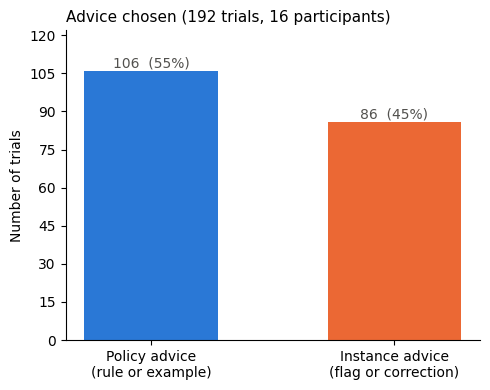

In [4]:
SCOPES = ['policy', 'instance']
LABELS = {'policy': 'Policy advice\n(rule or example)', 'instance': 'Instance advice\n(flag or correction)'}
COLORS = {'policy': '#2a78d6', 'instance': '#eb6834'}  # categorical slots 1-2, validated

counts = trials['choice_scope'].value_counts().reindex(SCOPES, fill_value=0)
total = counts.sum()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar([LABELS[s] for s in SCOPES], counts.values, color=[COLORS[s] for s in SCOPES], width=0.55)
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n, f"{n}  ({n / total:.0%})",
            ha='center', va='bottom', fontsize=10, color='#52514e')
ax.set_ylabel('Number of trials')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(f"Advice chosen ({total} trials, {trials['participant'].nunique()} participants)",
             fontsize=11, loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

## How many problems did they mark wrong?

Each trial has 3 problems, each marked right or wrong. Systematic trials really have **3** wrong problems; slip trials really have **1**. The highlighted bar is the count that matches the truth.

Note: bars count *how many* problems were marked wrong, not *which*. In the slip panel the "1" bar is split into trials where the one problem marked wrong was the real error, and trials where it was a correct problem instead. Per-problem accuracy is printed below.

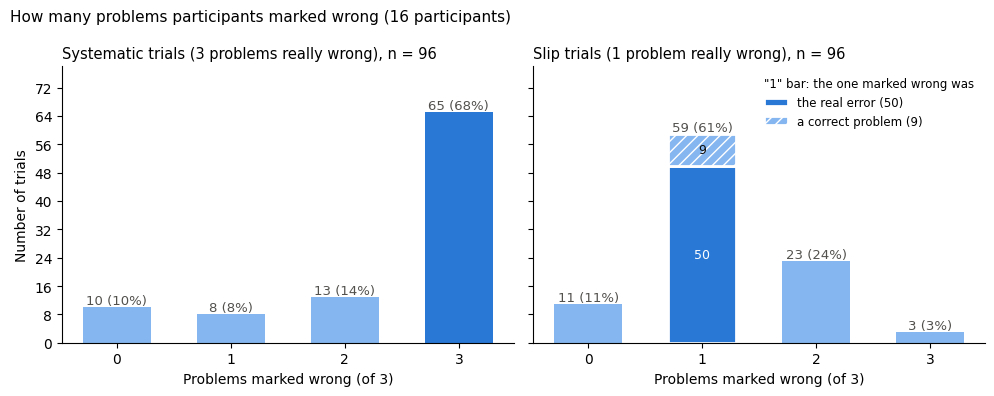

Overall per-problem marking accuracy: 78% (451/576)
  right problems in slip trials: 78% (150/192)
  wrong problems in slip trials: 75% (72/96)
  wrong problems in systematic trials: 80% (229/288)


In [5]:
# one row per problem shown (3 per trial), used for accuracy below
marks = pd.DataFrame([
    {'participant': t.participant, 'trial_index': t.trial_index, 'error_type': t.error_type,
     'problem': p['problem_index'], 'actually_wrong': p['is_error'],
     'marked': t.marks[i], 'mark_correct': t.marks_correct[i]}
    for t in trials.itertuples() for i, p in enumerate(t.problems)
])

TRUE_WRONG = {'systematic': 3, 'slip': 1}
PANEL_TITLES = {'systematic': 'Systematic trials (3 problems really wrong)', 'slip': 'Slip trials (1 problem really wrong)'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, et in zip(axes, ERROR_TYPES):
    sub = trials[trials['error_type'] == et]
    counts_wrong = sub['n_marked_wrong'].value_counts().reindex(range(4), fill_value=0)
    colors = ['#2a78d6' if k == TRUE_WRONG[et] else '#86b6ef' for k in range(4)]
    bars = ax.bar(range(4), counts_wrong.values, color=colors, width=0.6)
    for bar, n in zip(bars, counts_wrong.values):
        ax.text(bar.get_x() + bar.get_width() / 2, n, f"{n} ({n / len(sub):.0%})",
                ha='center', va='bottom', fontsize=9.5, color='#52514e')
    if et == 'slip':
        # split the "1 marked wrong" bar by WHICH problem: the real error, or a correct one
        one = sub[sub['n_marked_wrong'] == 1]
        hit = int(one['target_marked_wrong'].sum())
        miss = len(one) - hit
        ax.bar(1, hit, color='#2a78d6', width=0.6, edgecolor='white', linewidth=2,
               label=f'the real error ({hit})')
        ax.bar(1, miss, bottom=hit, color='#86b6ef', width=0.6, edgecolor='white', linewidth=2, hatch='///',
               label=f'a correct problem ({miss})')
        for y, v in ((hit / 2, hit), (hit + miss / 2, miss)):
            if v:
                ax.text(1, y, str(v), ha='center', va='center', fontsize=9, color='#0b0b0b' if y > hit else 'white')
        ax.legend(frameon=False, fontsize=8.5, loc='upper right', title='"1" bar: the one marked wrong was', title_fontsize=8.5,
                  alignment='left')
    ax.set_xticks(range(4), ['0', '1', '2', '3'])
    ax.set_xlabel('Problems marked wrong (of 3)')
    ax.set_title(f"{PANEL_TITLES[et]}, n = {len(sub)}", fontsize=10.5, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Number of trials')
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].set_ylim(0, trials.groupby('error_type')['n_marked_wrong'].value_counts().max() * 1.2)
fig.suptitle(f"How many problems participants marked wrong ({trials['participant'].nunique()} participants)",
             fontsize=11, x=0.01, ha='left')
plt.tight_layout()
plt.show()

print(f"Overall per-problem marking accuracy: {marks['mark_correct'].mean():.0%} ({marks['mark_correct'].sum()}/{len(marks)})")
for (et, wrong), g in marks.groupby(['error_type', 'actually_wrong']):
    kind = 'wrong problems' if wrong else 'right problems'
    print(f"  {kind} in {et} trials: {g['mark_correct'].mean():.0%} ({g['mark_correct'].sum()}/{len(g)})")

In [6]:
# marking accuracy per participant (36 marks each)
per_person = marks.groupby('participant')['mark_correct'].agg(correct='sum', marks='count', accuracy='mean')
per_person['accuracy'] = per_person['accuracy'].map('{:.0%}'.format)
per_person

,correct,marks,accuracy
participant,,,
116RZppuqYOCS9X2xxNH,15,36,42%
3MiGqDtTYC5qMGOuXiQA,36,36,100%
5SV6nPSiYRoczNgTWDJp,35,36,97%
8V8xC9Yn3IcSGESsuxfT,34,36,94%
FSNHFOeR0xo41yA4lgeb,12,36,33%
Kkwerabhni7XvJwzzSXm,18,36,50%
SkLcqaMwsWQQhKvXpWry,30,36,83%
Uoqpo8zzdMqqXoI62Gzh,32,36,89%
WIB6Wt9waAeGICP5vwSp,14,36,39%


## Policy vs instance advice, by error type

Systematic = all 3 problems wrong (same mistake each time). Slip = 1 of the 3 problems wrong. Percentages are within each error type.

choice_scope  policy  instance
error_type                    
systematic        64        32
slip              42        54 



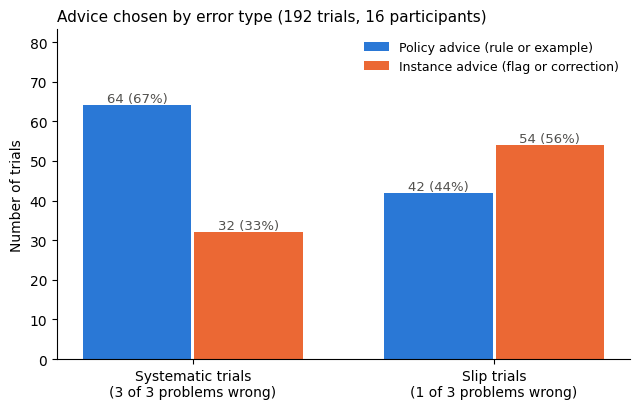

In [7]:
by_type = (trials.groupby('error_type')['choice_scope'].value_counts()
           .unstack(fill_value=0).reindex(index=ERROR_TYPES, columns=SCOPES, fill_value=0))
print(by_type, '\n')

x = np.arange(len(ERROR_TYPES))
width = 0.36
gap = 0.01  # small surface gap between the paired bars

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for i, scope in enumerate(SCOPES):
    offset = (i - 0.5) * (width + gap)
    bars = ax.bar(x + offset, by_type[scope].values, width, color=COLORS[scope],
                  label=LABELS[scope].replace('\n', ' '))
    for bar, et in zip(bars, ERROR_TYPES):
        n, tot = by_type.loc[et, scope], by_type.loc[et].sum()
        ax.text(bar.get_x() + bar.get_width() / 2, n, f"{n} ({n / tot:.0%})",
                ha='center', va='bottom', fontsize=9.5, color='#52514e')

ax.set_xticks(x, [ET_LABELS[et] for et in ERROR_TYPES])
ax.set_ylabel('Number of trials')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title(f"Advice chosen by error type ({len(trials)} trials, {trials['participant'].nunique()} participants)",
             fontsize=11, loc='left')
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, by_type.values.max() * 1.3)
plt.tight_layout()
plt.show()

## Policy vs instance advice, per participant

One column per participant (12 trials each), sorted by how often they chose policy advice. Under each column: a participant number (P1, P2, ... in plot order, not an ID) and their marking accuracy.

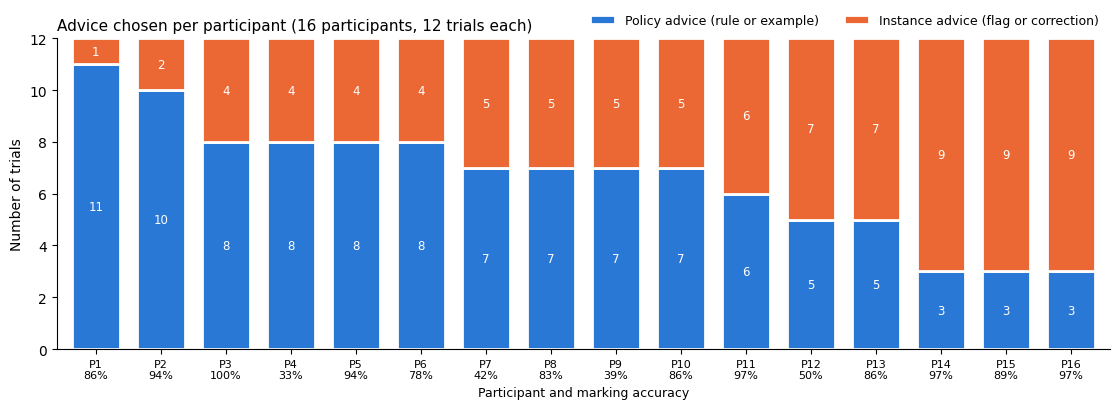

In [8]:
pp = (trials.groupby('participant')['choice_scope'].value_counts()
      .unstack(fill_value=0).reindex(columns=SCOPES, fill_value=0))
pp = pp.loc[pp['policy'].sort_values(ascending=False).index]   # most policy on the left
acc_pp = marks.groupby('participant')['mark_correct'].mean()
xlabels = [f"P{k}\n{acc_pp[p]:.0%}" for k, p in enumerate(pp.index, start=1)]   # numbered in plot order, no IDs

fig, ax = plt.subplots(figsize=(min(14, 0.55 * len(pp) + 2.5), 4.2))
bottom = np.zeros(len(pp))
for scope in SCOPES:
    vals = pp[scope].values
    ax.bar(range(len(pp)), vals, bottom=bottom, color=COLORS[scope], width=0.75,
           edgecolor='white', linewidth=2, label=LABELS[scope].replace('\n', ' '))
    for x, (b, v) in enumerate(zip(bottom, vals)):
        if v:
            ax.text(x, b + v / 2, str(v), ha='center', va='center', fontsize=8.5, color='white')
    bottom += vals

ax.set_xticks(range(len(pp)), xlabels, fontsize=8)
ax.set_xlim(-0.6, len(pp) - 0.4)
ax.set_ylim(0, pp.sum(axis=1).max())
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_ylabel('Number of trials')
ax.set_xlabel('Participant and marking accuracy', fontsize=9)
ax.set_title(f"Advice chosen per participant ({len(pp)} participants, 12 trials each)", fontsize=11, loc='left')
ax.legend(frameon=False, fontsize=9, loc='lower right', bbox_to_anchor=(1, 1.0), ncol=2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## H1 within each person: policy share, systematic vs slip

Each line is one participant: the share of their 6 systematic trials and 6 slip trials where they chose policy advice. H1 predicts lines that go **down** from systematic to slip (more policy for systematic errors). Lines are nudged slightly apart so overlapping ones stay visible. The black line is the mean.

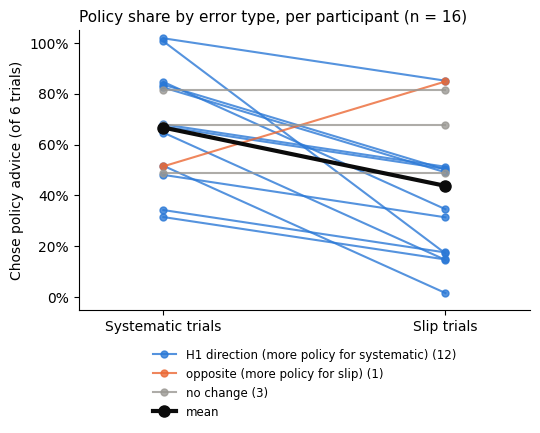

Mean policy share: systematic 67%, slip 44% (mean within-person difference +23%)


In [9]:
share = (trials.assign(policy=trials['choice_scope'].eq('policy'))
         .pivot_table(index='participant', columns='error_type', values='policy', aggfunc='mean')
         [ERROR_TYPES])
share['diff'] = share['systematic'] - share['slip']
DIRECTION = {'H1 direction (more policy for systematic)': ('#2a78d6', share['diff'] > 0),
             'opposite (more policy for slip)': ('#eb6834', share['diff'] < 0),
             'no change': ('#9a9893', share['diff'] == 0)}

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for label, (color, mask) in DIRECTION.items():
    for k, (_, row) in enumerate(share[mask].iterrows()):
        jit = rng.uniform(-0.02, 0.02)
        ax.plot([0, 1], [row['systematic'] + jit, row['slip'] + jit], color=color, lw=1.5, alpha=0.8,
                marker='o', ms=5, label=f"{label} ({mask.sum()})" if k == 0 else None)
ax.plot([0, 1], share[ERROR_TYPES].mean().values, color='#0b0b0b', lw=3, marker='o', ms=8, label='mean', zorder=5)

ax.set_xticks([0, 1], ['Systematic trials', 'Slip trials'])
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.05, 1.05)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylabel('Chose policy advice (of 6 trials)')
ax.set_title(f"Policy share by error type, per participant (n = {len(share)})", fontsize=11, loc='left')
ax.legend(frameon=False, fontsize=8.5, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Mean policy share: systematic {share['systematic'].mean():.0%}, slip {share['slip'].mean():.0%} "
      f"(mean within-person difference {share['diff'].mean():+.0%})")

## Advice by what participants saw (perceived error type)

Trials grouped by how many problems the participant **marked** wrong, whatever the truth: 3 = the trial looked systematic to them, 1 = it looked like a slip. If H1 holds, policy advice should be chosen more as more problems are marked wrong.

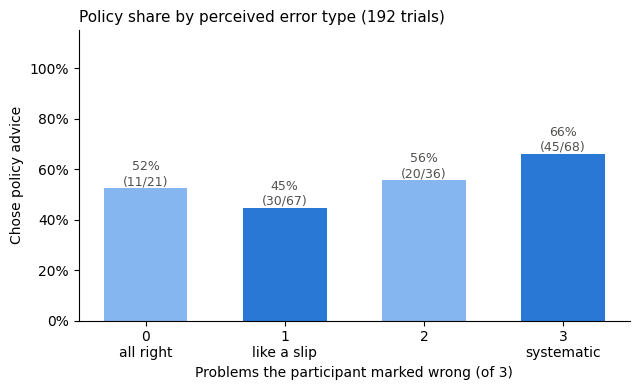

n_marked_wrong,0,1,2,3
error_type,,,,
systematic,60% (n=10),75% (n=8),62% (n=13),68% (n=65)
slip,45% (n=11),41% (n=59),52% (n=23),33% (n=3)


In [10]:
perc = trials.groupby('n_marked_wrong')['choice_scope'].agg(
    n='size', policy=lambda s: s.eq('policy').sum()).reindex(range(4), fill_value=0)
perc['share'] = perc['policy'] / perc['n'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(6.5, 4))
colors = ['#2a78d6' if k in (1, 3) else '#86b6ef' for k in range(4)]
bars = ax.bar(range(4), perc['share'].fillna(0).values, color=colors, width=0.6)
for bar, (k, row) in zip(bars, perc.iterrows()):
    if row['n']:
        ax.text(bar.get_x() + bar.get_width() / 2, row['share'], f"{row['share']:.0%}\n({int(row['policy'])}/{int(row['n'])})",
                ha='center', va='bottom', fontsize=9, color='#52514e')
ax.set_xticks(range(4), ['0\nall right', '1\nlike a slip', '2', '3\nsystematic'])
ax.set_xlabel('Problems the participant marked wrong (of 3)')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set_ylabel('Chose policy advice')
ax.set_title(f"Policy share by perceived error type ({len(trials)} trials)", fontsize=11, loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# same, split by the true error type (rows) - cells show policy share and number of trials
pd.crosstab(trials['error_type'], trials['n_marked_wrong'], values=trials['choice_scope'].eq('policy'),
            aggfunc=lambda s: f"{s.mean():.0%} (n={len(s)})").reindex(ERROR_TYPES).fillna('')

## Choice time

Time from the advice options unlocking (after the third problem is marked) to the participant's final pick. Each dot is one trial; the black bar is the median. Log scale, since a few long pauses would squash everything else.

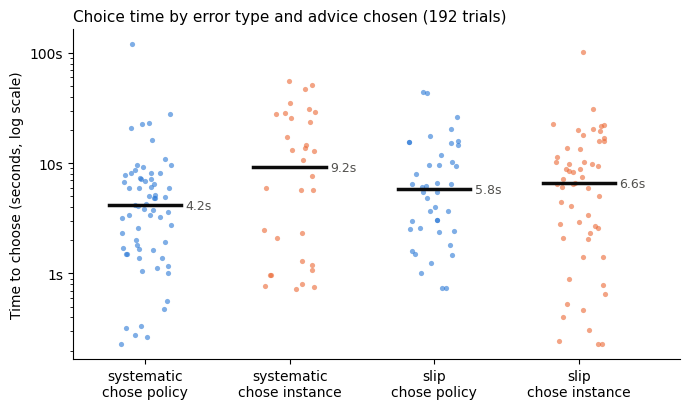

count  25%  50%   75%
error_type choice_scope                       
systematic policy         64.0  1.7  4.2   7.3
           instance       32.0  1.3  9.2  26.3
slip       policy         42.0  2.5  5.8  11.6
           instance       54.0  2.1  6.6  13.0

In [11]:
rt = trials.assign(choice_rt_s=trials['choice_rt_from_unlock_ms'] / 1000)
GROUPS = [(et, sc) for et in ERROR_TYPES for sc in SCOPES]
GROUP_LABELS = [f"{et}\nchose {sc}" for et, sc in GROUPS]

fig, ax = plt.subplots(figsize=(7, 4.2))
for x, (et, sc) in enumerate(GROUPS):
    vals = rt.loc[(rt['error_type'] == et) & (rt['choice_scope'] == sc), 'choice_rt_s'].dropna()
    vals = vals[vals > 0]
    ax.scatter(x + rng.uniform(-0.18, 0.18, len(vals)), vals, s=14, color=COLORS[sc], alpha=0.6, linewidths=0)
    if len(vals):
        med = vals.median()
        ax.plot([x - 0.25, x + 0.25], [med, med], color='#0b0b0b', lw=2.5)
        ax.text(x + 0.28, med, f"{med:.1f}s", va='center', fontsize=9, color='#52514e')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:g}s"))
ax.set_xticks(range(len(GROUPS)), GROUP_LABELS)
ax.set_xlim(-0.5, len(GROUPS) - 0.3)
ax.set_ylabel('Time to choose (seconds, log scale)')
ax.set_title(f"Choice time by error type and advice chosen ({len(rt)} trials)", fontsize=11, loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

rt.groupby(['error_type', 'choice_scope'])['choice_rt_s'].describe()[['count', '25%', '50%', '75%']].round(1).reindex(GROUPS)